
VITERBI ALGORITHM FOR PHONEME DECODING
Word: 'hello'

Observation Sequence: ['O1', 'O2', 'O3', 'O4']


 Generating HMM Matrices Visualization...


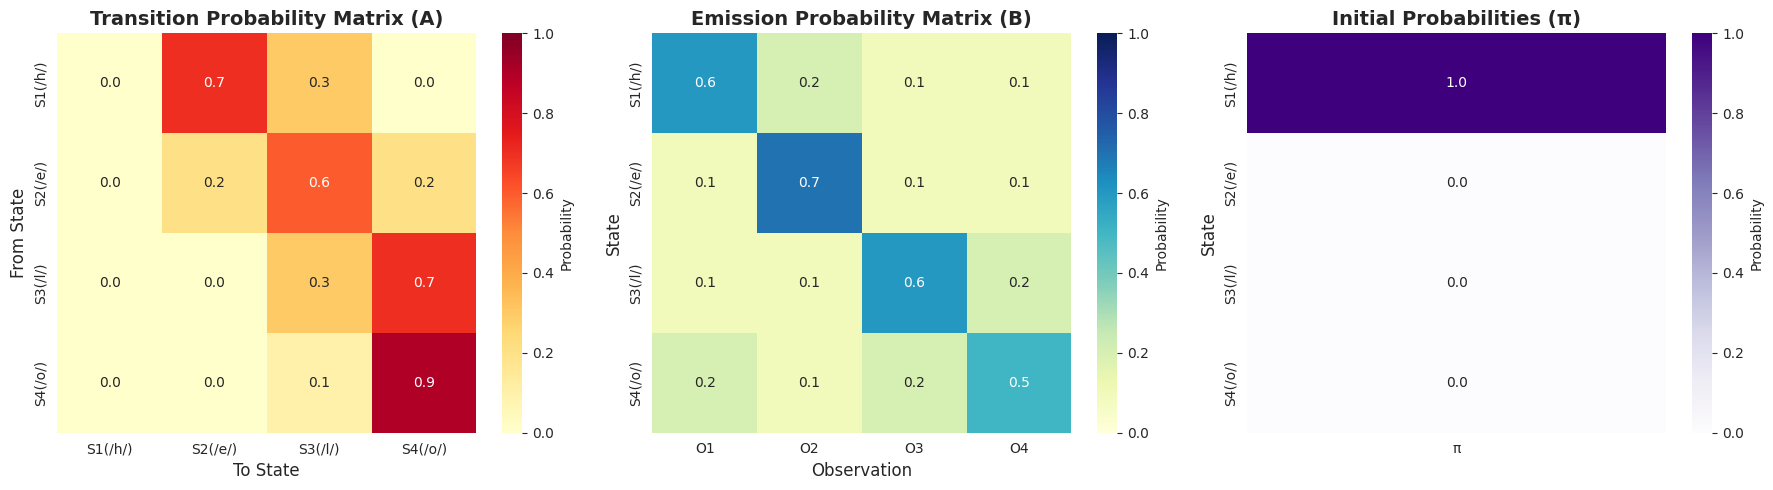


 Generating State Transition Diagram...


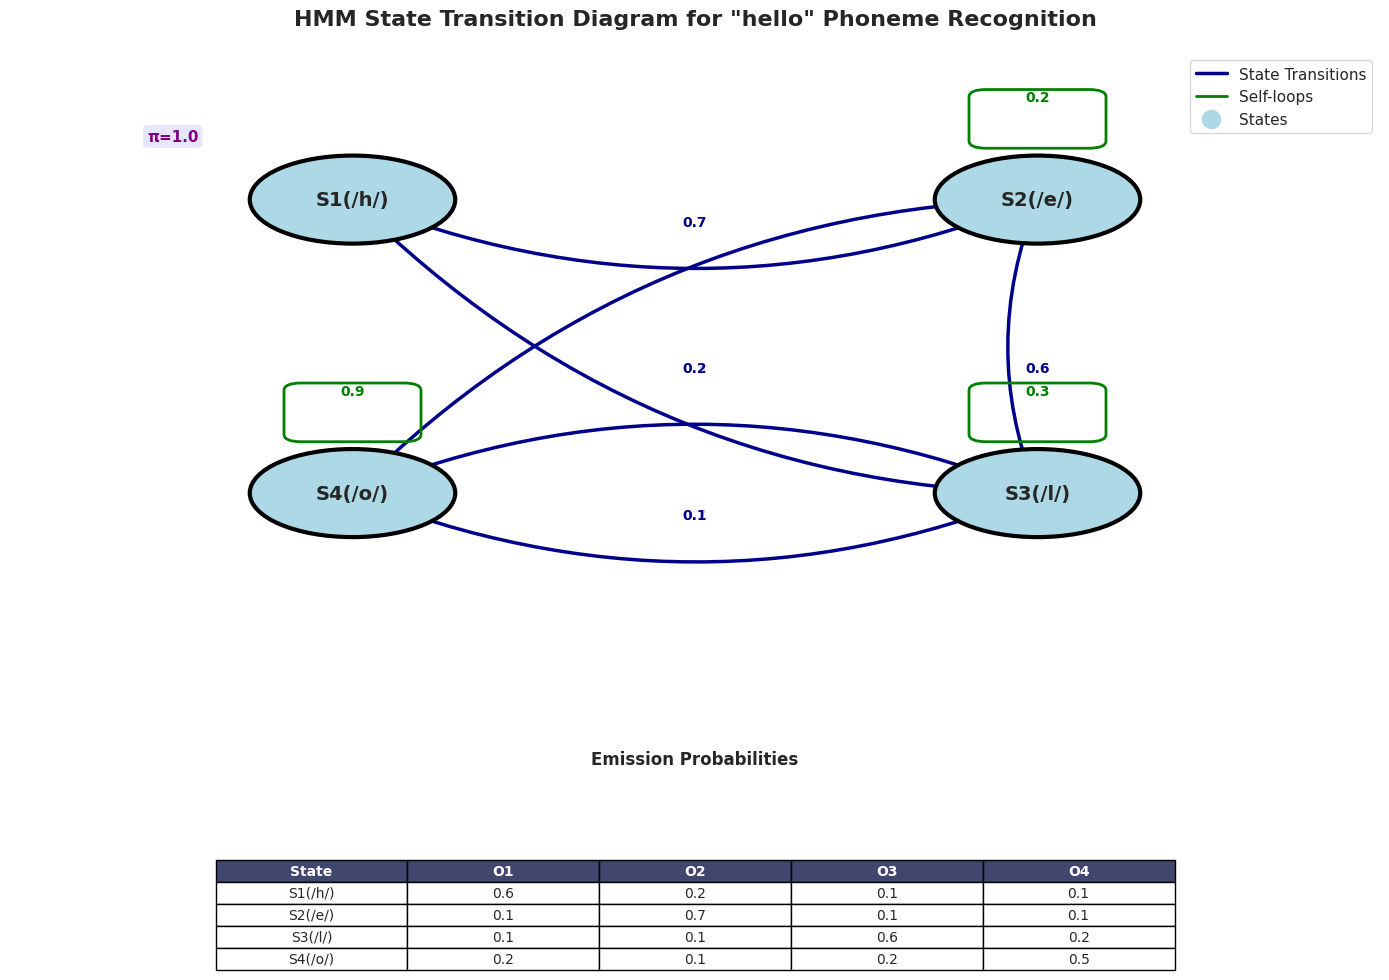

Viterbi Algorithm Steps:

Step 1: Initialization (t=0, Observation=O1)
----------------------------------------------------------------------
S1(/h/): π(S1(/h/)) × B(S1(/h/),O1) = 1.0000 × 0.6000 = 0.6000
S2(/e/): π(S2(/e/)) × B(S2(/e/),O1) = 0.0000 × 0.1000 = 0.0000
S3(/l/): π(S3(/l/)) × B(S3(/l/),O1) = 0.0000 × 0.1000 = 0.0000
S4(/o/): π(S4(/o/)) × B(S4(/o/),O1) = 0.0000 × 0.2000 = 0.0000

Step 2: Recursion (t=1, Observation=O2)
----------------------------------------------------------------------
S1(/h/): max[δ(t-1,i) × a(i,j)] × b(j,O2) = 0.600000 × 0.00 × 0.20 = 0.000000 (from S1(/h/))
S2(/e/): max[δ(t-1,i) × a(i,j)] × b(j,O2) = 0.600000 × 0.70 × 0.70 = 0.294000 (from S1(/h/))
S3(/l/): max[δ(t-1,i) × a(i,j)] × b(j,O2) = 0.600000 × 0.30 × 0.10 = 0.018000 (from S1(/h/))
S4(/o/): max[δ(t-1,i) × a(i,j)] × b(j,O2) = 0.600000 × 0.00 × 0.10 = 0.000000 (from S1(/h/))

Step 3: Recursion (t=2, Observation=O3)
----------------------------------------------------------------------
S1(/h/): m

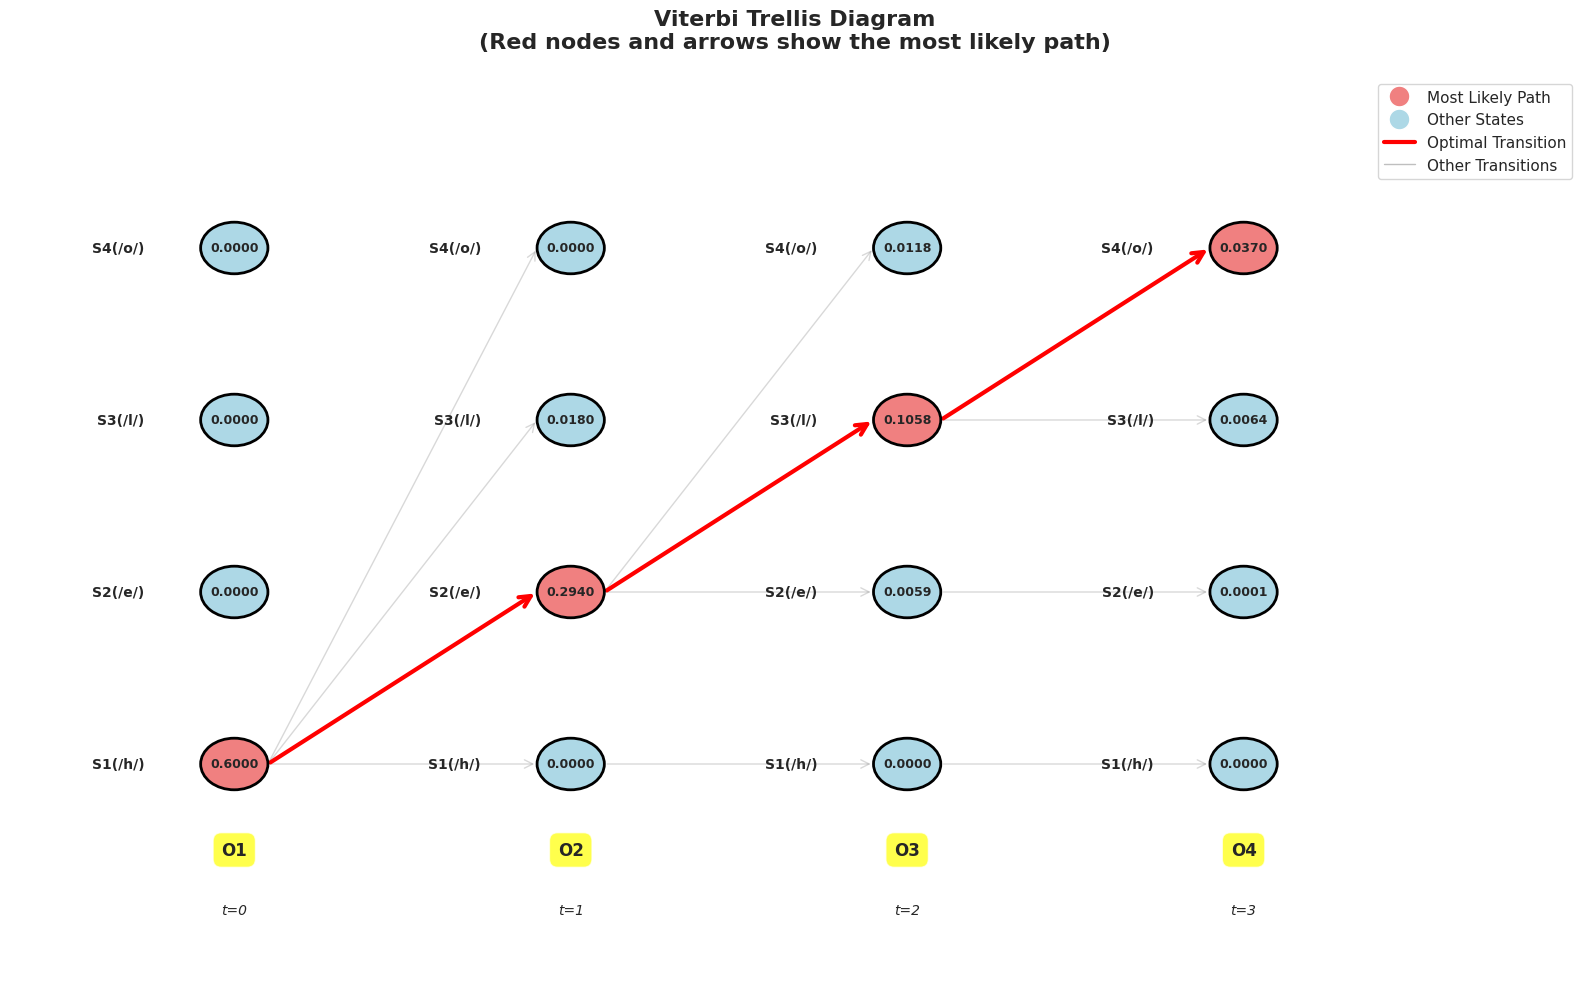


 Generating Probability Evolution Graphs...


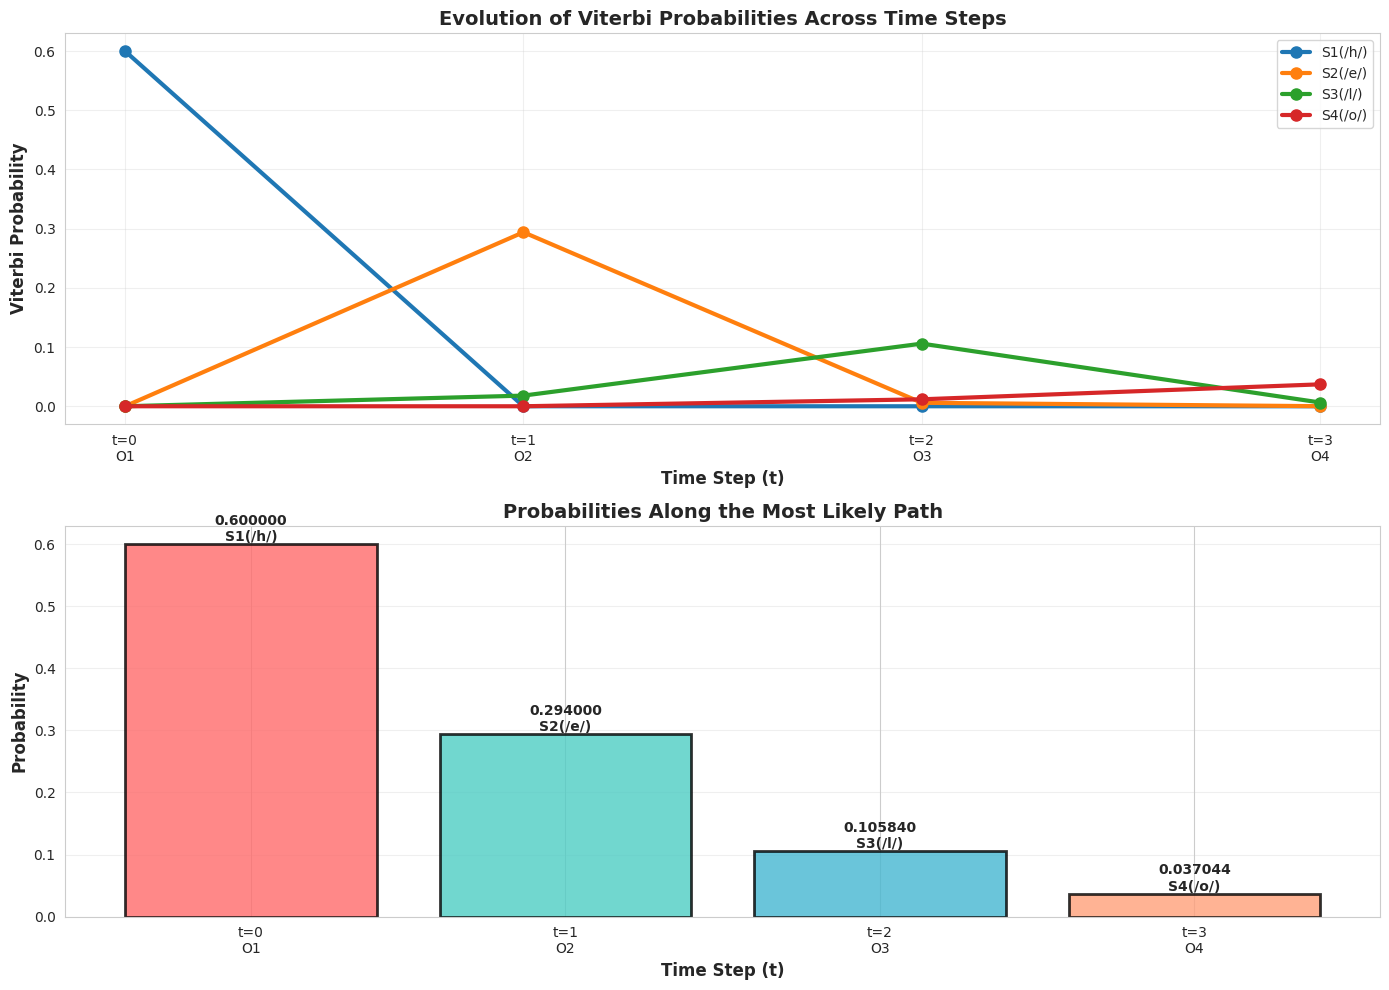


 Generating Final Decoding Result...


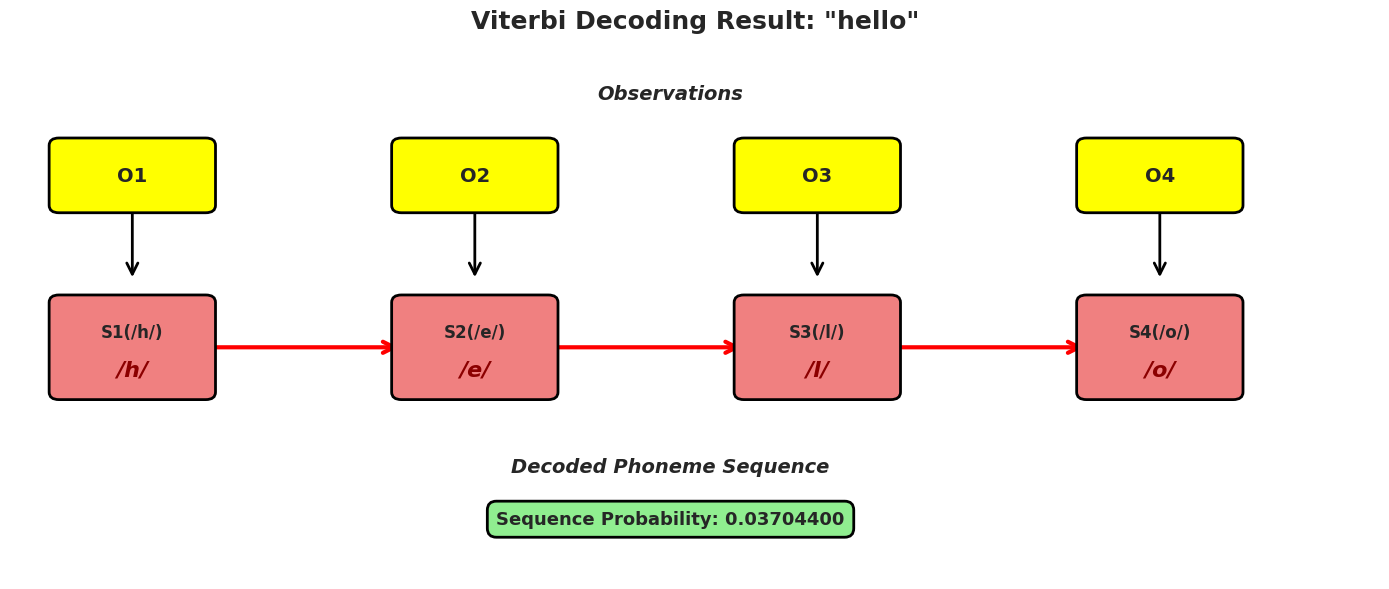


FINAL RESULTS

Observation Sequence: ['O1', 'O2', 'O3', 'O4']

Most Likely State Sequence: ['S1(/h/)', 'S2(/e/)', 'S3(/l/)', 'S4(/o/)']

Phoneme Sequence: ['/h/', '/e/', '/l/', '/o/']

Probability of Most Likely Sequence: 0.03704400
Log Probability: -1.4313

INFERENCE

The Viterbi algorithm has decoded the observation sequence [O1, O2, O3, O4]
to the most probable phoneme sequence: /h/ → /e/ → /l/ → /o/

This phoneme sequence represents the word 'hello' with a probability
of 0.03704400, confirming that the HMM correctly identifies
the hidden phoneme states from the observed acoustic features.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.patches import Rectangle

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Define the HMM parameters
states = ['S1(/h/)', 'S2(/e/)', 'S3(/l/)', 'S4(/o/)']
observations = ['O1', 'O2', 'O3', 'O4']
n_states = len(states)
n_obs = len(observations)

# Transition Probability Matrix (A)
A = np.array([
    [0.0, 0.7, 0.3, 0.0],  # From S1(/h/)
    [0.0, 0.2, 0.6, 0.2],  # From S2(/e/)
    [0.0, 0.0, 0.3, 0.7],  # From S3(/l/)
    [0.0, 0.0, 0.1, 0.9]   # From S4(/o/)
])

# Emission Probability Matrix (B)
B = np.array([
    [0.6, 0.2, 0.1, 0.1],  # S1(/h/) emitting O1, O2, O3, O4
    [0.1, 0.7, 0.1, 0.1],  # S2(/e/) emitting O1, O2, O3, O4
    [0.1, 0.1, 0.6, 0.2],  # S3(/l/) emitting O1, O2, O3, O4
    [0.2, 0.1, 0.2, 0.5]   # S4(/o/) emitting O1, O2, O3, O4
])

# Initial Probabilities (π)
pi = np.array([1.0, 0.0, 0.0, 0.0])  # Start with S1(/h/)

# Observation sequence (indices: 0->O1, 1->O2, 2->O3, 3->O4)
obs_sequence = [0, 1, 2, 3]  # [O1, O2, O3, O4]

def visualize_matrices():
    """Visualize the HMM matrices"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Transition Matrix
    sns.heatmap(A, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=states, yticklabels=states,
                ax=axes[0], cbar_kws={'label': 'Probability'}, vmin=0, vmax=1)
    axes[0].set_title('Transition Probability Matrix (A)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('To State', fontsize=12)
    axes[0].set_ylabel('From State', fontsize=12)

    # Emission Matrix
    sns.heatmap(B, annot=True, fmt='.1f', cmap='YlGnBu',
                xticklabels=observations, yticklabels=states,
                ax=axes[1], cbar_kws={'label': 'Probability'}, vmin=0, vmax=1)
    axes[1].set_title('Emission Probability Matrix (B)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Observation', fontsize=12)
    axes[1].set_ylabel('State', fontsize=12)

    # Initial Probabilities
    sns.heatmap(pi.reshape(-1, 1), annot=True, fmt='.1f', cmap='Purples',
                yticklabels=states, xticklabels=['π'],
                ax=axes[2], cbar_kws={'label': 'Probability'}, vmin=0, vmax=1)
    axes[2].set_title('Initial Probabilities (π)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('State', fontsize=12)

    plt.tight_layout()
    plt.savefig('hmm_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_viterbi_trellis(viterbi_matrix, path_matrix, most_likely_path):
    """Visualize the Viterbi trellis diagram"""
    fig, ax = plt.subplots(figsize=(16, 10))

    T = viterbi_matrix.shape[1]

    # Draw grid
    for t in range(T):
        for s in range(n_states):
            # Draw nodes
            color = 'lightcoral' if s == most_likely_path[t] else 'lightblue'
            circle = plt.Circle((t*3, s*2), 0.3, color=color, ec='black', linewidth=2, zorder=3)
            ax.add_patch(circle)

            # Add probability text
            prob_text = f'{viterbi_matrix[s, t]:.4f}'
            ax.text(t*3, s*2, prob_text, ha='center', va='center',
                   fontsize=9, fontweight='bold', zorder=4)

            # Add state label
            ax.text(t*3-0.8, s*2, states[s], ha='right', va='center',
                   fontsize=10, fontweight='bold')

    # Draw transitions
    for t in range(1, T):
        for s in range(n_states):
            prev_s = path_matrix[s, t]

            # Highlight the most likely path
            if s == most_likely_path[t] and prev_s == most_likely_path[t-1]:
                arrow = FancyArrowPatch(((t-1)*3+0.3, prev_s*2), (t*3-0.3, s*2),
                                      arrowstyle='->', mutation_scale=20, linewidth=3,
                                      color='red', zorder=2)
            else:
                arrow = FancyArrowPatch(((t-1)*3+0.3, prev_s*2), (t*3-0.3, s*2),
                                      arrowstyle='->', mutation_scale=15, linewidth=1,
                                      color='gray', alpha=0.3, zorder=1)
            ax.add_patch(arrow)

    # Add observation labels
    for t in range(T):
        ax.text(t*3, -1, f'{observations[obs_sequence[t]]}',
               ha='center', va='center', fontsize=12,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
               fontweight='bold')
        ax.text(t*3, -1.7, f't={t}', ha='center', va='center', fontsize=10, style='italic')

    # Formatting
    ax.set_xlim(-2, T*3)
    ax.set_ylim(-2.5, n_states*2)
    ax.axis('off')
    ax.set_title('Viterbi Trellis Diagram\n(Red nodes and arrows show the most likely path)',
                fontsize=16, fontweight='bold', pad=20)

    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral',
               markersize=15, label='Most Likely Path'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
               markersize=15, label='Other States'),
        Line2D([0], [0], color='red', linewidth=3, label='Optimal Transition'),
        Line2D([0], [0], color='gray', linewidth=1, alpha=0.5, label='Other Transitions')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.savefig('viterbi_trellis.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_probability_evolution(viterbi_matrix, most_likely_path):
    """Visualize how probabilities evolve over time"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    T = viterbi_matrix.shape[1]
    time_steps = range(T)

    # Plot 1: All state probabilities over time
    for s in range(n_states):
        linestyle = '-' if s in most_likely_path else '--'
        linewidth = 3 if s in most_likely_path else 1.5
        alpha = 1.0 if s in most_likely_path else 0.5
        ax1.plot(time_steps, viterbi_matrix[s, :], marker='o',
                label=states[s], linestyle=linestyle, linewidth=linewidth,
                alpha=alpha, markersize=8)

    ax1.set_xlabel('Time Step (t)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Viterbi Probability', fontsize=12, fontweight='bold')
    ax1.set_title('Evolution of Viterbi Probabilities Across Time Steps',
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(time_steps)
    ax1.set_xticklabels([f't={t}\n{observations[obs_sequence[t]]}' for t in time_steps])

    # Plot 2: Most likely path probabilities
    path_probs = [viterbi_matrix[most_likely_path[t], t] for t in range(T)]
    bars = ax2.bar(time_steps, path_probs, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'],
                   edgecolor='black', linewidth=2, alpha=0.8)

    # Add value labels on bars
    for i, (bar, prob) in enumerate(zip(bars, path_probs)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{prob:.6f}\n{states[most_likely_path[i]]}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax2.set_xlabel('Time Step (t)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Probability', fontsize=12, fontweight='bold')
    ax2.set_title('Probabilities Along the Most Likely Path', fontsize=14, fontweight='bold')
    ax2.set_xticks(time_steps)
    ax2.set_xticklabels([f't={t}\n{observations[obs_sequence[t]]}' for t in time_steps])
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('probability_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_state_transition_diagram():
    """Visualize the HMM state transition diagram"""
    fig, ax = plt.subplots(figsize=(14, 10))

    # State positions (arranged in a circular pattern)
    positions = {
        0: (2, 7),   # S1
        1: (6, 7),   # S2
        2: (6, 3),   # S3
        3: (2, 3)    # S4
    }

    # Draw states
    for i, (state, pos) in enumerate(positions.items()):
        circle = plt.Circle(pos, 0.6, color='lightblue', ec='black', linewidth=3, zorder=3)
        ax.add_patch(circle)
        ax.text(pos[0], pos[1], states[i], ha='center', va='center',
               fontsize=14, fontweight='bold', zorder=4)

        # Add initial probability
        if pi[i] > 0:
            ax.annotate(f'π={pi[i]:.1f}', xy=pos, xytext=(pos[0]-1.2, pos[1]+0.8),
                       fontsize=11, fontweight='bold', color='purple',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lavender'))

    # Draw transitions
    for i in range(n_states):
        for j in range(n_states):
            if A[i, j] > 0:
                start = positions[i]
                end = positions[j]

                if i == j:  # Self-loop
                    angle = 45 if i < 2 else -45
                    arc = FancyBboxPatch((start[0]-0.3, start[1]+0.8), 0.6, 0.6,
                                        boxstyle="round,pad=0.1",
                                        ec='green', linewidth=2, fill=False, zorder=2)
                    ax.add_patch(arc)
                    ax.text(start[0], start[1]+1.3, f'{A[i, j]:.1f}',
                           ha='center', va='bottom', fontsize=10,
                           fontweight='bold', color='green')
                else:
                    # Calculate offset for curved arrows
                    dx = end[0] - start[0]
                    dy = end[1] - start[1]

                    arrow = FancyArrowPatch(start, end, arrowstyle='->',
                                          mutation_scale=25, linewidth=2.5,
                                          color='darkblue',
                                          connectionstyle="arc3,rad=0.2", zorder=2)
                    ax.add_patch(arrow)

                    # Add probability label
                    mid_x = (start[0] + end[0]) / 2
                    mid_y = (start[1] + end[1]) / 2
                    offset = 0.3 if dy > 0 else -0.3
                    ax.text(mid_x, mid_y + offset, f'{A[i, j]:.1f}',
                           ha='center', va='center', fontsize=10,
                           fontweight='bold', color='darkblue',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    # Add emission probabilities table
    table_data = []
    for i in range(n_states):
        row = [states[i]] + [f'{B[i, j]:.1f}' for j in range(n_obs)]
        table_data.append(row)

    table = ax.table(cellText=table_data,
                    colLabels=['State'] + observations,
                    cellLoc='center', loc='bottom',
                    bbox=[0.15, -0.25, 0.7, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style the header
    for i in range(n_obs + 1):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    ax.text(4, -0.5, 'Emission Probabilities', ha='center', va='top',
           fontsize=12, fontweight='bold')

    ax.set_xlim(0, 8)
    ax.set_ylim(-1, 9)
    ax.axis('off')
    ax.set_title('HMM State Transition Diagram for "hello" Phoneme Recognition',
                fontsize=16, fontweight='bold', pad=20)

    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='darkblue', linewidth=2.5, label='State Transitions'),
        Line2D([0], [0], color='green', linewidth=2, label='Self-loops'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
               markersize=15, label='States')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.savefig('state_transition_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_final_results(most_likely_path, probability):
    """Visualize the final decoded sequence"""
    fig, ax = plt.subplots(figsize=(14, 6))

    T = len(most_likely_path)

    # Create flowchart-style visualization
    for t in range(T):
        state_idx = most_likely_path[t]
        phoneme = states[state_idx].split('(')[1].strip(')')

        # Observation box
        obs_box = FancyBboxPatch((t*3.5, 3), 1.5, 0.8,
                                boxstyle="round,pad=0.1",
                                facecolor='yellow', edgecolor='black',
                                linewidth=2, zorder=3)
        ax.add_patch(obs_box)
        ax.text(t*3.5 + 0.75, 3.4, observations[obs_sequence[t]],
               ha='center', va='center', fontsize=14, fontweight='bold')

        # Arrow
        arrow = FancyArrowPatch((t*3.5 + 0.75, 3), (t*3.5 + 0.75, 2),
                              arrowstyle='->', mutation_scale=20,
                              linewidth=2, color='black', zorder=2)
        ax.add_patch(arrow)

        # State box
        state_box = FancyBboxPatch((t*3.5, 0.5), 1.5, 1.2,
                                  boxstyle="round,pad=0.1",
                                  facecolor='lightcoral', edgecolor='black',
                                  linewidth=2, zorder=3)
        ax.add_patch(state_box)
        ax.text(t*3.5 + 0.75, 1.3, states[state_idx],
               ha='center', va='center', fontsize=12, fontweight='bold')
        ax.text(t*3.5 + 0.75, 0.8, phoneme,
               ha='center', va='center', fontsize=16, fontweight='bold',
               color='darkred', style='italic')

        # Connection arrow
        if t < T - 1:
            conn_arrow = FancyArrowPatch((t*3.5 + 1.5, 1.1), ((t+1)*3.5, 1.1),
                                       arrowstyle='->', mutation_scale=20,
                                       linewidth=3, color='red', zorder=1)
            ax.add_patch(conn_arrow)

    # Add title and labels
    ax.text(T*3.5/2 - 0.75, 4.5, 'Observations', ha='center', va='center',
           fontsize=14, fontweight='bold', style='italic')
    ax.text(T*3.5/2 - 0.75, -0.5, 'Decoded Phoneme Sequence', ha='center', va='center',
           fontsize=14, fontweight='bold', style='italic')

    # Add probability
    ax.text(T*3.5/2 - 0.75, -1.2, f'Sequence Probability: {probability:.8f}',
           ha='center', va='center', fontsize=13, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen',
                    edgecolor='black', linewidth=2))

    ax.set_xlim(-0.5, T*3.5 - 0.5)
    ax.set_ylim(-2, 5)
    ax.axis('off')
    ax.set_title('Viterbi Decoding Result: "hello"', fontsize=18, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('final_decoding_result.png', dpi=300, bbox_inches='tight')
    plt.show()

def viterbi(obs_seq, states, pi, A, B, visualize=True):
    """
    Viterbi Algorithm implementation

    Parameters:
    - obs_seq: sequence of observation indices
    - states: list of state names
    - pi: initial state probabilities
    - A: transition probability matrix
    - B: emission probability matrix
    - visualize: whether to create visualizations

    Returns:
    - most_likely_path: most probable sequence of states
    - max_probability: probability of the most likely path
    - viterbi_matrix: the complete Viterbi matrix
    - path_matrix: the path tracking matrix
    """
    n_states = len(states)
    T = len(obs_seq)

    # Initialize Viterbi matrix and path matrix
    viterbi_matrix = np.zeros((n_states, T))
    path_matrix = np.zeros((n_states, T), dtype=int)

    # Step 1: Initialization (t=0)
    viterbi_matrix[:, 0] = pi * B[:, obs_seq[0]]

    print("Viterbi Algorithm Steps:")
    print("=" * 70)
    print(f"\nStep 1: Initialization (t=0, Observation={observations[obs_seq[0]]})")
    print("-" * 70)
    for i, state in enumerate(states):
        print(f"{state}: π({state}) × B({state},{observations[obs_seq[0]]}) = "
              f"{pi[i]:.4f} × {B[i, obs_seq[0]]:.4f} = {viterbi_matrix[i, 0]:.4f}")

    # Step 2: Recursion (t=1 to T-1)
    for t in range(1, T):
        print(f"\nStep {t+1}: Recursion (t={t}, Observation={observations[obs_seq[t]]})")
        print("-" * 70)

        for j in range(n_states):
            # Calculate probability for each previous state
            prob_array = viterbi_matrix[:, t-1] * A[:, j] * B[j, obs_seq[t]]

            # Find maximum and store
            viterbi_matrix[j, t] = np.max(prob_array)
            path_matrix[j, t] = np.argmax(prob_array)

            # Print details
            max_prev_state = np.argmax(prob_array)
            print(f"{states[j]}: max[δ(t-1,i) × a(i,j)] × b(j,{observations[obs_seq[t]]}) = "
                  f"{viterbi_matrix[max_prev_state, t-1]:.6f} × {A[max_prev_state, j]:.2f} × "
                  f"{B[j, obs_seq[t]]:.2f} = {viterbi_matrix[j, t]:.6f} (from {states[max_prev_state]})")

    # Step 3: Termination
    print(f"\nStep {T+1}: Termination")
    print("-" * 70)
    max_probability = np.max(viterbi_matrix[:, T-1])
    last_state = np.argmax(viterbi_matrix[:, T-1])
    print(f"Maximum probability: {max_probability:.6f}")
    print(f"Last state: {states[last_state]}")

    # Step 4: Backtracking
    print(f"\nStep {T+2}: Backtracking")
    print("-" * 70)
    most_likely_path = [last_state]
    for t in range(T-1, 0, -1):
        last_state = path_matrix[last_state, t]
        most_likely_path.insert(0, last_state)

    return most_likely_path, max_probability, viterbi_matrix, path_matrix

# Run Viterbi Algorithm
print("\n" + "="*70)
print("VITERBI ALGORITHM FOR PHONEME DECODING")
print("Word: 'hello'")
print("="*70)
print(f"\nObservation Sequence: {[observations[i] for i in obs_sequence]}")
print()

# First, visualize the HMM matrices
print("\n Generating HMM Matrices Visualization...")
visualize_matrices()

# Visualize state transition diagram
print("\n Generating State Transition Diagram...")
visualize_state_transition_diagram()

# Run Viterbi algorithm
most_likely_path, probability, viterbi_matrix, path_matrix = viterbi(
    obs_sequence, states, pi, A, B
)

# Visualize Viterbi trellis
print("\n  Generating Viterbi Trellis Diagram...")
visualize_viterbi_trellis(viterbi_matrix, path_matrix, most_likely_path)

# Visualize probability evolution
print("\n Generating Probability Evolution Graphs...")
visualize_probability_evolution(viterbi_matrix, most_likely_path)

# Visualize final results
print("\n Generating Final Decoding Result...")
visualize_final_results(most_likely_path, probability)

# Display results
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(f"\nObservation Sequence: {[observations[i] for i in obs_sequence]}")
print(f"\nMost Likely State Sequence: {[states[i] for i in most_likely_path]}")
print(f"\nPhoneme Sequence: {[states[i].split('(')[1].strip(')') for i in most_likely_path]}")
print(f"\nProbability of Most Likely Sequence: {probability:.8f}")
print(f"Log Probability: {np.log10(probability):.4f}")

# Inference
print("\n" + "="*70)
print("INFERENCE")
print("="*70)
phoneme_seq = ' → '.join([states[i].split('(')[1].strip(')') for i in most_likely_path])
print(f"\nThe Viterbi algorithm has decoded the observation sequence [O1, O2, O3, O4]")
print(f"to the most probable phoneme sequence: {phoneme_seq}")
print(f"\nThis phoneme sequence represents the word 'hello' with a probability")
print(f"of {probability:.8f}, confirming that the HMM correctly identifies")
print(f"the hidden phoneme states from the observed acoustic features.")
print("\n" + "="*70)
